## 1) Setup

In [ ]:

import os, time, itertools
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import numpy as np
from PIL import Image

# Metrics & plots
try:
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
except Exception as e:
    print("scikit-learn not available. Some metrics will be skipped:", e)
    classification_report = None
    confusion_matrix = None
    accuracy_score = None

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2) Configuration

In [ ]:

DATA_DIR = Path('/content/drive/MyDrive/imagenet-sample-images-master')  # change if needed
BATCH_SIZE = 32
NUM_WORKERS = 2

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


## 3) Data Loading

In [ ]:

def has_subdirs(p: Path):
    return any(d.is_dir() for d in p.iterdir())

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

class FlatFolderDataset(torch.utils.data.Dataset):
    def __init__(self, root: Path, transform=None):
        self.root = Path(root)
        self.transform = transform
        exts = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff', '.webp'}
        self.paths = [p for p in self.root.iterdir() if p.suffix.lower() in exts]
        self.classes = ['unknown']
        self.class_to_idx = {'unknown': 0}
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert("RGB")
        if self.transform:
            img = self.transform(img)
        target = 0
        return img, target, str(p)

if DATA_DIR.exists():
    if has_subdirs(DATA_DIR):
        ds = datasets.ImageFolder(str(DATA_DIR), transform=transform)
        use_imagefolder = True
        print(f"Loaded ImageFolder with {len(ds)} images across {len(ds.classes)} classes.")
    else:
        ds = FlatFolderDataset(DATA_DIR, transform=transform)
        use_imagefolder = False
        print(f"Loaded flat folder with {len(ds)} images (single pseudo-class).")
else:
    raise FileNotFoundError(f"DATA_DIR not found: {DATA_DIR}")

dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
class_names = ds.classes if hasattr(ds, 'classes') else ['unknown']
class_names


Loaded flat folder with 100 images (single pseudo-class).


['unknown']

## 4) Model: DenseNet-121 (ImageNet)

In [ ]:

try:
    from torchvision.models import DenseNet121_Weights
    weights = DenseNet121_Weights.IMAGENET1K_V1
    model = models.densenet121(weights=weights)
    note = "Using DenseNet-121 (weights enum)."
except Exception:
    model = models.densenet121(pretrained=True)
    note = "Using DenseNet-121 (pretrained=True fallback)."

model.eval().to(device)
print(note)
print("Classifier:", model.classifier)


Using DenseNet-121 (weights enum).
Classifier: Linear(in_features=1024, out_features=1000, bias=True)


## 8) Grad‑CAM (jacobgil/pytorch-grad-cam style)

In [ ]:
pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 117.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
captum 0.8.0 requires numpy<2.0, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.


pytorch-grad-cam imported successfully.


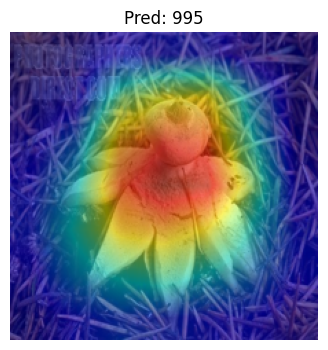

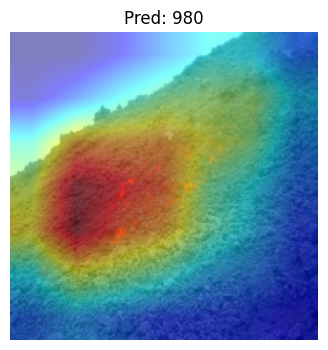

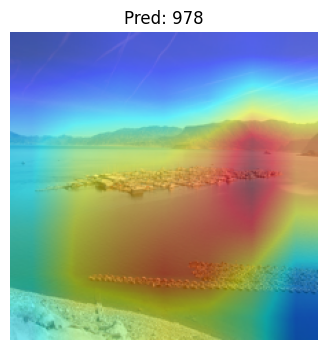

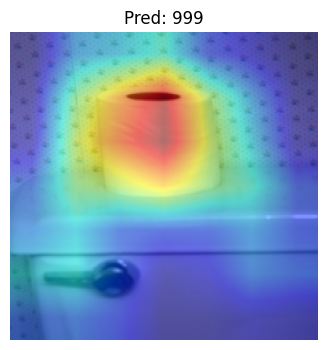

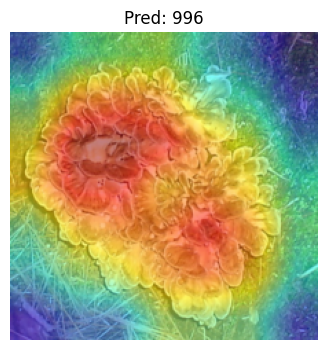

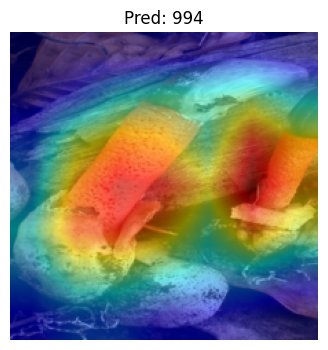

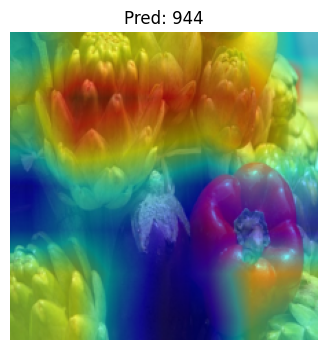

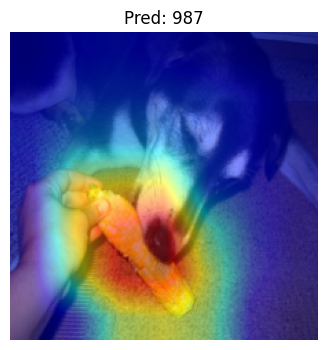

In [ ]:

# Try to import pytorch-grad-cam. If missing, this section will skip gracefully.
try:
    from pytorch_grad_cam import GradCAM, HiResCAM, GradCAMPlusPlus, XGradCAM, EigenCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
    has_cam = True
    print("pytorch-grad-cam imported successfully.")
except Exception as e:
    has_cam = False
    print("pytorch-grad-cam not available. Install with `pip install grad-cam` to enable. Error:", e)

def denormalize_to_rgb(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    x = img_tensor.cpu() * std + mean
    x = x.clamp(0,1).permute(1,2,0).numpy()
    return x  # HWC in [0,1]

if has_cam:
    # Pick up to 8 samples
    sample_indices = list(range(min(8, len(ds))))
    sample_imgs = []
    for i in sample_indices:
        item = ds[i]
        img = item[0] if use_imagefolder else item[0]
        sample_imgs.append(img.unsqueeze(0))
    if not sample_imgs:
        print("No images available for Grad-CAM.")
    else:
        batch = torch.cat(sample_imgs).to(device)
        model.eval()

        # Target layers as recommended for DenseNet: last features block
        target_layers = [model.features[-1]]

        with torch.no_grad():
            logits = model(batch)
            preds = logits.argmax(1).tolist()
        targets = [ClassifierOutputTarget(p) for p in preds]

        # Choose CAM method here (GradCAM is default)
        with GradCAM(model=model, target_layers=target_layers) as cam:
            grayscale_cams = cam(input_tensor=batch, targets=targets)  # [N, H, W]

        # Visualize
        for i in range(len(sample_indices)):
            rgb = denormalize_to_rgb(batch[i])
            cam_img = show_cam_on_image(rgb, grayscale_cams[i], use_rgb=True)
            plt.figure(figsize=(4,4))
            plt.imshow(cam_img)
            title = f"Pred: {class_names[preds[i]] if preds[i] < len(class_names) else preds[i]}"
            plt.title(title)
            plt.axis('off')
            plt.show()
else:
    print("Skipping Grad-CAM visualizations (library not available).")


In [ ]:
from imutils import paths
from PIL import Image
import torch
from torchvision import transforms, models

# Path to your images
image_path = '/content/drive/MyDrive/imagenet-sample-images-master'

# Collect all image file paths
imagepaths = list(paths.list_images(image_path))

# Preprocessing: resize, to tensor, normalize with ImageNet mean/std
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load first 100 images
images100 = []
for i in range(min(100, len(imagepaths))):
    img = Image.open(imagepaths[i]).convert("RGB")
    img = preprocess(img)
    images100.append(img)

# Stack into a batch tensor
X100 = torch.stack(images100).to(device)   # shape: (N, 3, 224, 224)

# Load DenseNet-121 pretrained
model = models.densenet121(weights="IMAGENET1K_V1").to(device).eval()

# Run inference
with torch.no_grad():
    logits = model(X100)
    preds = logits.argmax(1)

print("Predicted class indices:", preds.tolist())



Predicted class indices: [995, 980, 978, 999, 996, 994, 944, 987, 949, 945, 816, 880, 953, 964, 689, 467, 923, 933, 997, 943, 935, 469, 927, 878, 985, 979, 983, 959, 956, 728, 965, 942, 941, 963, 930, 979, 981, 947, 932, 946, 879, 617, 982, 963, 958, 893, 939, 550, 957, 922, 974, 989, 892, 894, 954, 986, 882, 940, 988, 971, 895, 955, 968, 962, 929, 926, 992, 973, 924, 972, 947, 881, 978, 938, 875, 975, 990, 877, 890, 948, 888, 896, 951, 884, 993, 952, 891, 509, 925, 984, 886, 435, 934, 969, 936, 937, 966, 977, 950, 967]


Got CAMs for 100 images


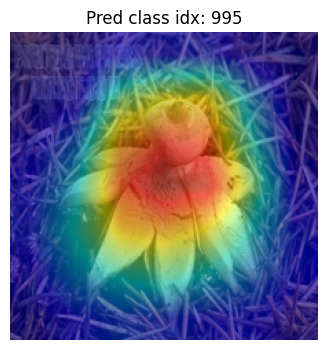

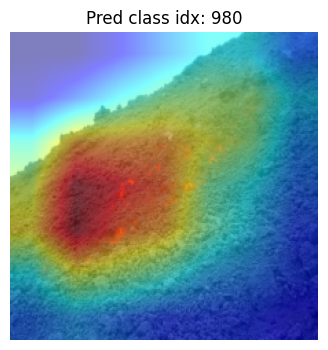

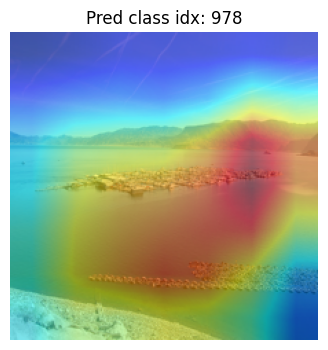

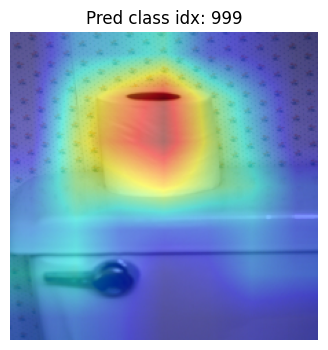

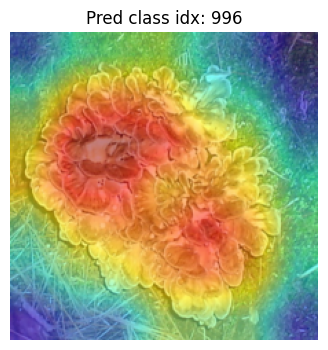

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import numpy as np

# Choose target layer (last DenseNet features block works well)
target_layers = [model.features[-1]]

# Run model once to get predicted classes for each of the 100 images
with torch.no_grad():
    logits = model(X100)
    preds = logits.argmax(1).cpu().tolist()

# Create GradCAM object
cam = GradCAM(model=model, target_layers=target_layers)

# Compute CAMs for all 100 images
targets = [ClassifierOutputTarget(p) for p in preds]
grayscale_cams = cam(input_tensor=X100, targets=targets)   # shape: (100, H, W)

print("Got CAMs for", len(grayscale_cams), "images")

# ---- visualize a few (example: first 5) ----
def denorm_for_vis(img_tensor):
    # De-normalize to [0,1] for overlay
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    x = img_tensor.cpu() * std + mean
    x = x.clamp(0,1).permute(1,2,0).numpy()
    return x

for i in range(5):
    rgb = denorm_for_vis(X100[i])
    cam_img = show_cam_on_image(rgb, grayscale_cams[i], use_rgb=True)
    plt.figure(figsize=(4,4))
    plt.imshow(cam_img)
    plt.title(f"Pred class idx: {preds[i]}")
    plt.axis('off')
    plt.show()


In [ ]:
gradvec = []

# grayscale_cams is (100, H, W)
for k in range(100):
    flat = grayscale_cams[k].reshape(-1)   # flatten to (224*224,)
    gradvec.append(flat.tolist())          # convert to list if you need Python list

print(len(gradvec))       # 100
print(len(gradvec[0]))    # 224*224 = 50176


100
50176


### **GradCAM Plus Plus**

In [ ]:
from pathlib import Path
import torch, numpy as np
save_dir = Path("./artifacts"); save_dir.mkdir(parents=True, exist_ok=True)

# Ensure CPU copies
X100_cpu = X100.detach().cpu()
# If you also have logits as a single tensor, detach+cpu it; otherwise skip
# logits_cpu = logits.detach().cpu()

# Try to capture ImageNet category names (optional)
try:
    from torchvision.models import DenseNet121_Weights
    imagenet_categories = DenseNet121_Weights.IMAGENET1K_V1.meta.get("categories", None)
except Exception:
    imagenet_categories = None

# 1) Pack tensors/metadata with torch.save
torch.save({
    "X100": X100_cpu,                           # (N,3,224,224), normalized
    "preds": preds,                             # list[int] length N
    # "logits": logits_cpu,                     # optional if available
    "class_names": class_names,                 # from ImageFolder (or ['unknown'])
    "imagepaths": imagepaths[:len(X100_cpu)],   # file paths used
    "preprocess": {                             # reproducibility
        "img_size": 224,
        "mean": [0.485, 0.456, 0.406],
        "std":  [0.229, 0.224, 0.225],
    },
    "imagenet_categories": imagenet_categories, # optional
    "model_name": "densenet121"
}, save_dir/"batch100.pt")

# 2) Save CAMs + flattened vectors as compressed numpy
np.savez_compressed(save_dir/"cams_batch100.npz",
                    gradcam=grayscale_cams)

# c) Flattened vectors
np.savez_compressed(save_dir/"gradvec_batch100.npz",
                    gradvec_gradcam=gradvec)
   # (N,H*W) e.g., (100, 50176)

print("Saved:", (save_dir/"batch100.pt"))


NameError: name 'gradvec' is not defined

In [ ]:
from pathlib import Path
import torch, numpy as np
save_dir = Path("./artifacts"); save_dir.mkdir(parents=True, exist_ok=True)

# Ensure CPU copies
X100_cpu = X100.detach().cpu()
# If you also have logits as a single tensor, detach+cpu it; otherwise skip
# logits_cpu = logits.detach().cpu()

# Try to capture ImageNet category names (optional)
try:
    from torchvision.models import DenseNet121_Weights
    imagenet_categories = DenseNet121_Weights.IMAGENET1K_V1.meta.get("categories", None)
except Exception:
    imagenet_categories = None

# 1) Pack tensors/metadata with torch.save
torch.save({
    "X100": X100_cpu,
    "preds": preds,
    # "logits": logits_cpu,
    "class_names": class_names,
    "imagepaths": imagepaths[:len(X100_cpu)],
    "preprocess": {
        "img_size": 224,
        "mean": [0.485, 0.456, 0.406],
        "std":  [0.229, 0.224, 0.225],
    },
    "imagenet_categories": imagenet_categories, # optional
    "model_name": "densenet121"
}, save_dir/"batch100_pp.pt")

# 2) Save CAMs + flattened vectors as compressed numpy
np.savez_compressed(save_dir/"cam_pp_batch100.npz",
                    gradcam=grayscale_cams_pp)

# c) Flattened vectors
np.savez_compressed(save_dir/"gradvec_pp_batch100.npz",
                    gradvec_gradcam=gradvec_pp)
   # (N,H*W) e.g., (100, 50176)

print("Saved:", (save_dir/"batch100.pt"))


Saved: artifacts/batch100.pt


### *Partition SHAP*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 0) Collect first 100 images (HWC) like your Keras loop
from imutils import paths
from PIL import Image
import numpy as np

image_path = '/content/drive/MyDrive/imagenet-sample-images-master'
imagepaths = list(paths.list_images(image_path))

images = []
for i in range(min(100, len(imagepaths))):
    img = Image.open(imagepaths[i]).convert("RGB").resize((224, 224))
    images.append(np.array(img))                     # HWC, uint8
images = np.asarray(images)                          # (N,224,224,3)


In [ ]:
import json
from urllib.request import urlretrieve
import shap
import torch
import numpy as np
from PIL import Image


print("--- Starting SHAP Analysis ---")

# == Block A: Define the Prediction Function ==
def f(x_np):
    """Prediction function for SHAP."""
    # PyTorch needs (N, C, H, W)
    x_pt = torch.from_numpy(x_np.transpose((0, 3, 1, 2))).float().to(device)

    # Normalize the tensor
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
    x_pt_normalized = normalize(x_pt / 255.0)

    with torch.no_grad():
        output = model(x_pt_normalized)

    return torch.nn.functional.softmax(output, dim=-1).cpu().numpy()

print("✅ Prediction function 'f' is defined.")


# == Block B: Load Class Names ==
# Download and load the 1000 ImageNet class names.
try:
    url, filename = ("https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json", "imagenet_class_index.json")
    urlretrieve(url, filename)
    with open(filename) as f_json:
        class_names_json = json.load(f_json)
    class_names = [class_names_json[str(i)][1] for i in range(1000)]

    # CRITICAL CHECK: Ensure we have exactly 1000 class names.
    assert len(class_names) == 1000
    print(f" Class names loaded successfully. Total classes: {len(class_names)}.")

except Exception as e:
    print(f" ERROR loading class names: {e}")


# == Block C: Create the Explainer ==

images_to_explain = images
masker = shap.maskers.Image("blur(28,28)", images_to_explain[0].shape)
explainer = shap.Explainer(f, masker, output_names=class_names, algorithm="partition")
print("SHAP explainer created.")


# == Block D: Pre-calculate Top Indices ==

preds = f(images_to_explain)
top_indices = np.argmax(preds, axis=1)
print(f" Top prediction indices calculated. Shape: {top_indices.shape}.")


# == Block E: Run the Explainer ==

print("\n Starting SHAP calculation...")
part_shap_values = explainer(
    images_to_explain,
    max_evals=5000,
    batch_size=50,
    outputs=top_indices
)
print("\n SHAP values calculated successfully!")

--- Starting SHAP Analysis ---
✅ Prediction function 'f' is defined.
✅ Class names loaded successfully. Total classes: 1000.
✅ SHAP explainer created.
✅ Top prediction indices calculated. Shape: (100,).

🚀 Starting SHAP calculation...


  0%|          | 0/4998 [00:00<?, ?it/s]

  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer:   2%|▏         | 2/100 [00:00<?, ?it/s]

  0%|          | 0/4998 [00:00<?, ?it/s]

...

  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 100/100 [12:13<00:00,  7.43s/it]

  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer: 101it [12:20,  7.48s/it]



🎉 SHAP values calculated successfully!


In [ ]:
def partition_to_pixel_vectors(exp):
    """
    Build (N, 224*224) pixel-wise vectors from a SHAP explanation object.

    Strategy:
    1) Sum absolute SHAP values across color channels to get a single saliency map.
    2) If values are already pixel-wise (H,W), use them directly.
    3) If values are coarse (h,w), upscale them to the full image size.
    """
    N = len(exp)
    H, W, C = exp.data[0].shape
    out = np.zeros((N, H * W), dtype=np.float32)

    for i in range(N):
        v = np.asarray(exp.values[i])

        # Squeeze dimensions if shape is (h,w,c,1) -> (h,w,c)
        while v.ndim > 3 and v.shape[-1] == 1:
            v = v[..., 0]

        # Handle cases with multiple class outputs, e.g. (h,w,c,K) -> pick K=0
        if v.ndim == 4:
            v = v[..., 0]

        if v.ndim != 3:
            raise ValueError(f"Unexpected values shape for sample {i}: {v.shape}")

        h, w, c = v.shape

        # **CORRECTED STEP**: Sum absolute values across channels
        saliency = np.sum(np.abs(v), axis=-1).astype(np.float32)

        # Upscale the saliency map if its dimensions are smaller than the image
        if (h, w) == (H, W):
            pix = saliency
        elif (H % h == 0) and (W % w == 0):
            ry, rx = H // h, W // w
            pix = np.repeat(np.repeat(saliency, ry, axis=0), rx, axis=1)
        else:
            pix = np.array(
                Image.fromarray(saliency).resize((W, H), resample=Image.NEAREST),
                dtype=np.float32
            )

        out[i] = pix.reshape(-1)

    return out

# Convert the SHAP explanation into vectors for the metric analysis
partvec_pixel = partition_to_pixel_vectors(part_shap_values)

print("Shape of Partition SHAP pixel vectors:", partvec_pixel.shape)

Shape of Partition SHAP pixel vectors: (100, 50176)


In [ ]:
import pathlib
# 2. Define the directory and filename for saving
save_dir = pathlib.Path("./artifacts")
save_dir.mkdir(exist_ok=True, parents=True)
save_path = save_dir / "partition_shap_pixelized.npz"

# 3. Save the vectors and image paths to a compressed .npz file
#    np.savez_compressed is great for saving multiple numpy arrays together.
#    `dtype=object` is used for imagepaths to handle strings efficiently.
print(f"\nSaving results to: {save_path}")
np.savez_compressed(
    save_path,
    partvec_pixel=partvec_pixel,
    imagepaths=np.array(imagepaths, dtype=object)
)

print(" Successfully saved SHAP vectors and image paths.")


Saving results to: artifacts/partition_shap_pixelized.npz
✅ Successfully saved SHAP vectors and image paths.


In [ ]:
# 2) PyTorch model + f(x) (normalize inside; SHAP sees raw pixel space)
import torch, torch.nn.functional as F
from torchvision import models
from torchvision.models import DenseNet121_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
weights = DenseNet121_Weights.IMAGENET1K_V1
model = models.densenet121(weights=weights).eval().to(device)

class_names = weights.meta.get("categories", None)
mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)

def f(x_np: np.ndarray) -> np.ndarray:
    # x_np: (N,224,224,3) uint8 or 0..255 float
    xt = torch.from_numpy(x_np).permute(0,3,1,2).float().to(device) / 255.0
    xt = (xt - mean) / std
    with torch.inference_mode():
        logits = model(xt)
        probs = F.softmax(logits, dim=1).cpu().numpy()
    return probs


In [ ]:
# 5) Save for later so you don't need live Explanation again
import numpy as np, pathlib
save_dir = pathlib.Path("./artifacts"); save_dir.mkdir(exist_ok=True, parents=True)
np.savez_compressed(save_dir/"partition_shap_pixelized.npz",
                    partvec_pixel=partvec_pixel,
                    imagepaths=np.array(imagepaths, dtype=object))
print("Saved:", save_dir/"partition_shap_pixelized.npz")


Saved: artifacts/partition_shap_pixelized.npz


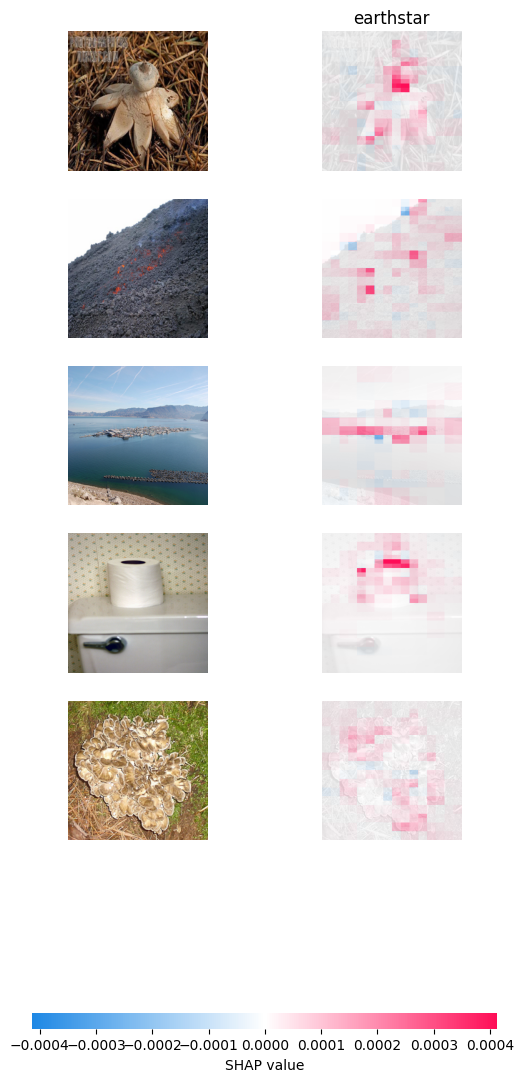

In [ ]:
# 3) Visualize a few explanations
# Works with the new Explanation object
shap.image_plot(part_shap_values[:5], images[:5])


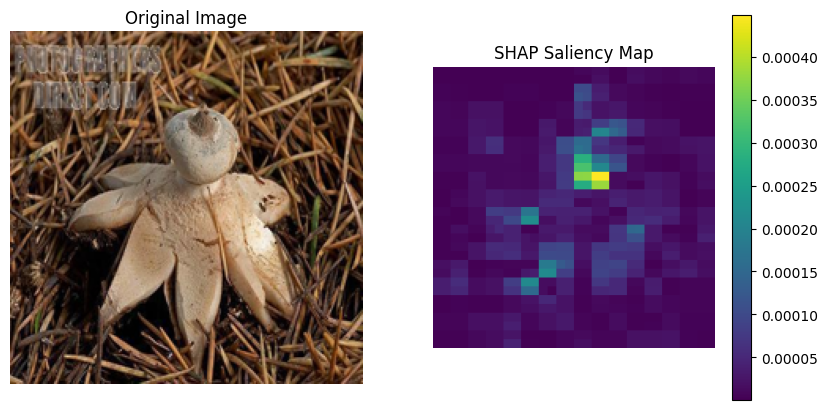


Statistics for SHAP vector at index 0:
  Min value:   1.6970130900517688e-07
  Max value:   0.0004489485581871122
  Mean value:  2.9103845008648932e-05
  Sum of values: 1.4603145122528076


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Visualization Cell ---

# Select an image index to inspect (e.g., the first one)
img_index = 0

# Get the original image and its corresponding SHAP vector
original_image = images[img_index]
shap_vector = partvec_pixel[img_index]

# Reshape the 1D SHAP vector back into a 2D image (224x224)
shap_heatmap = shap_vector.reshape(224, 224)

# Create a side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot the original image
axes[0].imshow(original_image)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Plot the SHAP heatmap
im = axes[1].imshow(shap_heatmap, cmap='viridis')
axes[1].set_title("SHAP Saliency Map")
axes[1].axis('off')

fig.colorbar(im, ax=axes[1])
plt.show()

# Print some statistics about the SHAP vector
print(f"\nStatistics for SHAP vector at index {img_index}:")
print(f"  Min value:   {np.min(shap_vector)}")
print(f"  Max value:   {np.max(shap_vector)}")
print(f"  Mean value:  {np.mean(shap_vector)}")
print(f"  Sum of values: {np.sum(shap_vector)}")

In [ ]:
import numpy as np
from pathlib import Path

# --- Setup: Define the path to your data ---
# Make sure this points to the folder containing your .npz files.
root = Path("/content/Values")

# Check if the directory exists to avoid errors
if not root.exists():
    print(f" Error: The directory '{root}' was not found.")
    print("Please update the 'root' variable to the correct path.")
else:
    print(f" Loading files from: {root}")

    # --- 1. Load Grad-CAM data ---
    try:
        gradcam_file = root / "gradvec_batch100.npz"
        gradcam_data = np.load(gradcam_file)
        print(f"\n Successfully loaded Grad-CAM file: '{gradcam_file.name}'")
        print(f"   Arrays inside: {gradcam_data.files}")
    except FileNotFoundError:
        print(f"    Warning: Grad-CAM file not found at '{gradcam_file}'")

    # --- 2. Load Grad-CAM++ data ---
    try:
        gradcam_pp_file = root / "gradvec_pp_batch100.npz"
        gradcam_pp_data = np.load(gradcam_pp_file)
        print(f"\n Successfully loaded Grad-CAM++ file: '{gradcam_pp_file.name}'")
        print(f"   Arrays inside: {gradcam_pp_data.files}")
    except FileNotFoundError:
        print(f"    Warning: Grad-CAM++ file not found at '{gradcam_pp_file}'")

    # --- 3. Load Partition SHAP data ---
    try:
        shap_file = root / "partition_shap_pixelized.npz"
        # allow_pickle=True is needed if the file contains non-numeric data, like your imagepaths
        shap_data = np.load(shap_file, allow_pickle=True)
        print(f"\n Successfully loaded Partition SHAP file: '{shap_file.name}'")
        print(f"   Arrays inside: {shap_data.files}")
    except FileNotFoundError:
        print(f"    Warning: Partition SHAP file not found at '{shap_file}'")




📁 Loading files from: /content/Values

✅ Successfully loaded Grad-CAM file: 'gradvec_batch100.npz'
   Arrays inside: ['gradvec_gradcam']

✅ Successfully loaded Grad-CAM++ file: 'gradvec_pp_batch100.npz'
   Arrays inside: ['gradvec_gradcam']

✅ Successfully loaded Partition SHAP file: 'partition_shap_pixelized.npz'
   Arrays inside: ['partvec_pixel', 'imagepaths']


In [ ]:
import numpy as np

# --- Pre-Ranking Step (The TensorFlow Method) ---
# Instead of normalizing, we will convert each vector into a list of ranks.
# This makes the comparison robust to different value distributions.

def vectors_to_ranks(vectors):
    """Converts a batch of value vectors into rank vectors using argsort."""
    # argsort gives the indices that would sort the array.
    # A second argsort gives the rank of each element.
    return vectors.argsort(axis=1).argsort(axis=1)

# Assume gradvec_pixel, gradppvec_pixel, and partvec_pixel are your loaded data
gradcam_ranks = vectors_to_ranks(gradvec_pixel)
gradcampp_ranks = vectors_to_ranks(gradppvec_pixel)
partvec_pixel_ranks = vectors_to_ranks(partvec_pixel)

print(" All vectors converted to ranks.")
print("Shape of Grad-CAM ranks:", gradcam_ranks.shape)
print("Shape of Partition SHAP ranks:", partvec_pixel_ranks.shape)

✅ All vectors converted to ranks.
Shape of Grad-CAM ranks: (100, 50176)
Shape of Partition SHAP ranks: (100, 50176)


In [ ]:
import math
def multcorr(a,b,c): #a-partition, b-gradcam, c-gradcam++ (3 variables)
  ans=[]
  for k in range(100):
    partvec1000 = a[k]
    gradvec1000 = b[k]
    gradppvec1000 = c[k]
    temp=[]
    r12=np.corrcoef(partvec1000,gradvec1000)
    r13=np.corrcoef(partvec1000, gradppvec1000)
    r23=np.corrcoef(gradvec1000, gradppvec1000)
    R1_23=math.sqrt((r12[0][1]*r12[0][1]+r13[0][1]*r13[0][1]-2*(r12[0][1]*r13[0][1]*r23[0][1]))/(1-r23[0][1]*r23[0][1]))
    R2_13=math.sqrt((r12[0][1]*r12[0][1]+r23[0][1]*r23[0][1]-2*(r12[0][1]*r23[0][1]*r13[0][1]))/(1-r13[0][1]*r13[0][1]))
    R3_12=math.sqrt((r13[0][1]*r13[0][1]+r23[0][1]*r23[0][1]-2*(r13[0][1]*r23[0][1]*r12[0][1]))/(1-r12[0][1]*r12[0][1]))
    temp.append(R1_23)
    temp.append(R2_13)
    temp.append(R3_12)
    ans.append(temp)
  return ans

------------------------------------------------------------


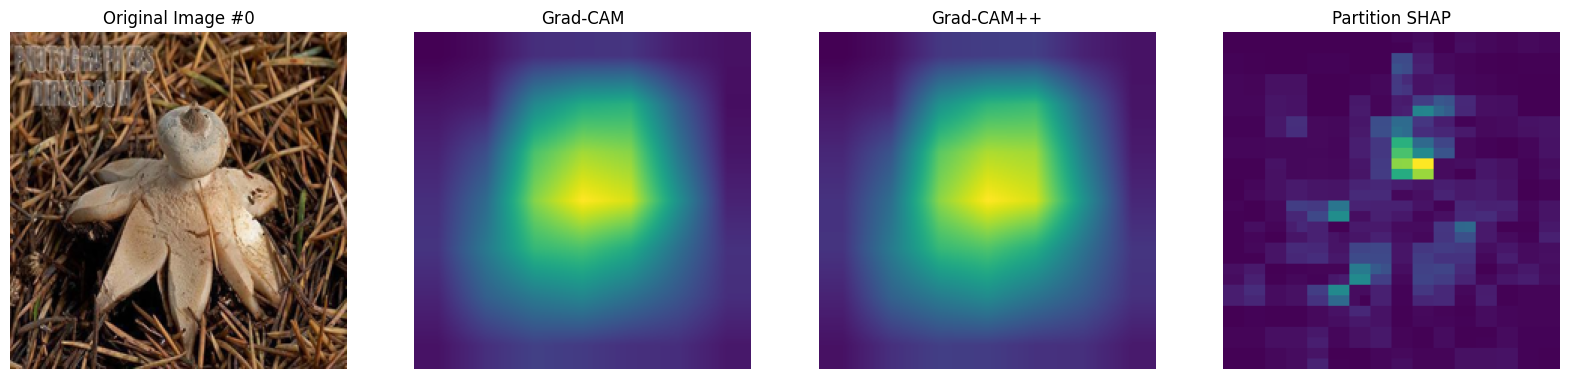

------------------------------------------------------------


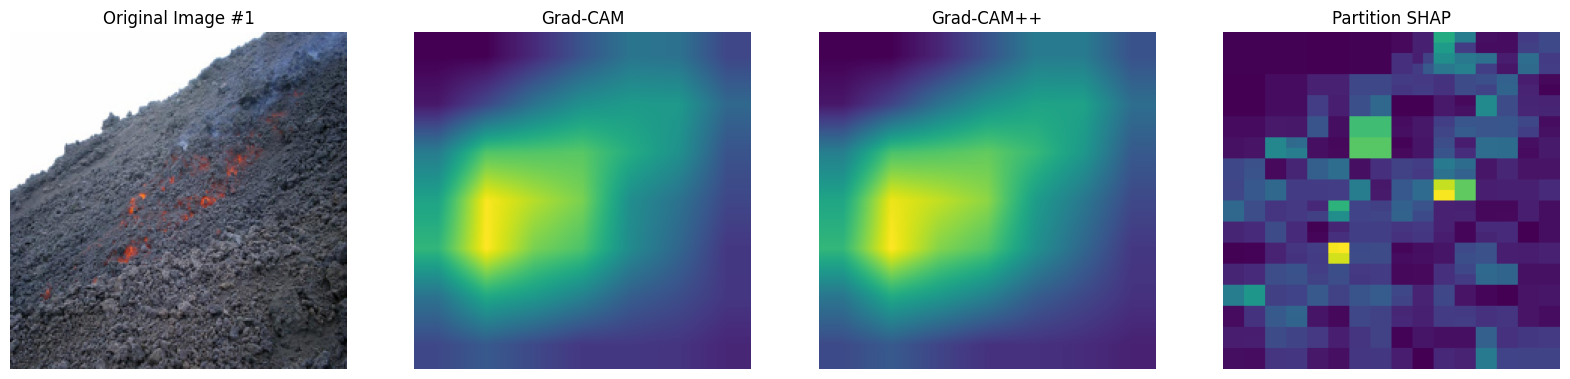

------------------------------------------------------------


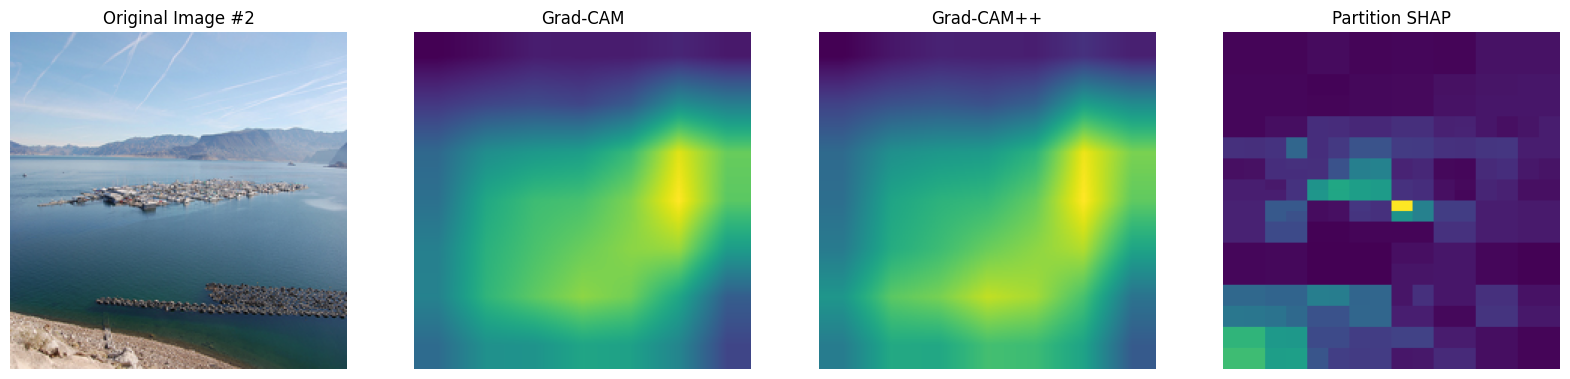

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Final Visual Diagnosis ---

def compare_heatmaps(img_index):
    """
    Displays the original image and the heatmaps from all three methods.
    """
    # Ensure all vectors are normalized for proper visualization
    def normalize_for_viz(vector):
        v_min, v_max = np.min(vector), np.max(vector)
        if v_max > v_min:
            return (vector - v_min) / (v_max - v_min)
        return vector # Avoid division by zero if flat

    # Get the data for the specified image
    original_image = images[img_index]
    gradcam_map = normalize_for_viz(gradvec_pixel[img_index]).reshape(224, 224)
    gradcampp_map = normalize_for_viz(gradppvec_pixel[img_index]).reshape(224, 224)
    shap_map = normalize_for_viz(partvec_pixel[img_index]).reshape(224, 224)

    # Create the plot
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(original_image)
    axes[0].set_title(f"Original Image #{img_index}")
    axes[0].axis('off')

    axes[1].imshow(gradcam_map, cmap='viridis')
    axes[1].set_title("Grad-CAM")
    axes[1].axis('off')

    axes[2].imshow(gradcampp_map, cmap='viridis')
    axes[2].set_title("Grad-CAM++")
    axes[2].axis('off')

    axes[3].imshow(shap_map, cmap='viridis')
    axes[3].set_title("Partition SHAP")
    axes[3].axis('off')

    plt.show()

# Visualize the results for the first few images
for i in range(3):
    print("-" * 60)
    compare_heatmaps(i)

In [ ]:
out=multcorr(partvec_pixel_norm,gradcam_vectors_norm,gradcampp_vectors_norm)
out

[[0.5035197361446294, 0.9991053710046651, 0.9991055728519602],
 [0.38273128114282934, 0.9974616085739948, 0.9974820543842515],
 [0.247209605895863, 0.9865077819279188, 0.9866210973092234],
 [0.34683086830096765, 0.9954057885274717, 0.9953586722602767],
 [0.4580798338582987, 0.9938054677520671, 0.9936415064034327],
 [0.4965184584818411, 0.992344708285698, 0.9920824039603882],
 [0.3723729197684911, 0.9482960384179014, 0.9492998592412144],
 [0.5775627712995768, 0.9903835082487786, 0.9900358783134809],
 [0.4106047051743664, 0.9970863917432343, 0.997053808704877],
 [0.4227346466242571, 0.9977621569581686, 0.9977804739986057],
 [0.32521879414664334, 0.9457762021680888, 0.943715293096065],
 [0.42374822492136394, 0.9943867609993152, 0.9944380854227219],
 [0.4657837827257353, 0.9949515087802996, 0.9949552606547682],
 [0.4583603054395622, 0.9968948565705029, 0.9968773206137604],
 [0.5222824963044523, 0.9915016612466712, 0.9916395552142944],
 [0.6400490899175149, 0.9899472351724964, 0.98973626764

In [ ]:
iout=[]
for i in range(100):
  x=np.argsort(out[i])[::-1][:1024]
  iout.append(x)
iout

[array([2, 1, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([2, 1

In [ ]:
#making 0as 1, 1as 2 ...
iout1=[]
for i in range(100):
  temp=iout[i]
  t=[x+1 for x in temp]
  iout1.append(t)
iout1

[[np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(3), np.int64(2), np.int

In [ ]:
def borda_count(votes):
    num_candidates = len(votes[0])
    scores = {candidate: 0 for candidate in range(1, num_candidates + 1)}

    for ballot in votes:
        for index, candidate in enumerate(ballot):
            scores[candidate] += num_candidates - index - 1

    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return sorted_scores

In [ ]:
ballots=iout1
result = borda_count(ballots)
print("Borda Count Result:")
for candidate, score in result:
    print(f"Candidate {candidate}: {score} points")

Borda Count Result:
Candidate 3: 159 points
Candidate 2: 141 points
Candidate 1: 0 points


In [ ]:
#final ranking - Multiple correlation
#based borda count ranking
borda_rank=[]
for candidate, score in result:
    borda_rank.append(candidate)
borda_rank

[3, 2, 1]

In [ ]:
import numpy as np
from scipy.stats import spearmanr

# Assume 'part_shap_values', 'gradvec_pixel', and 'gradppvec_pixel' are already calculated.

# --- 1. Process Partition SHAP Values (TensorFlow Method) ---

print("Processing Partition SHAP values using the TensorFlow notebook's method...")
# The original notebook used only the red channel and zeroed out negative values.
N = len(part_shap_values)
partvec_tf_method = np.zeros((N, 224 * 224), dtype=np.float32)

for i in range(N):
    # Get raw SHAP values for the i-th image, for the first (and only) explained class
    raw_values = part_shap_values.values[i]

    # Ensure shape is (h, w, c)
    if raw_values.ndim == 4:
        raw_values = raw_values[..., 0] # Handle (h,w,c,1) case

    # Select the RED channel only
    red_channel_values = raw_values[..., 0]

    # Set negative values to zero
    red_channel_values[red_channel_values < 0] = 0

    # Flatten and store
    partvec_tf_method[i] = red_channel_values.flatten()

print(f"SHAP processing complete. Shape: {partvec_tf_method.shape}")


# --- 2. Convert All Explanation Vectors to Ranks ---

print("\nConverting all explanation vectors to ranks using argsort...")
# This is the most critical step from the original notebook.
# We convert the matrices of values into matrices of ranks.
gradcam_ranks = gradvec_pixel.argsort(axis=1).argsort(axis=1)
gradcampp_ranks = gradppvec_pixel.argsort(axis=1).argsort(axis=1)
shap_ranks = partvec_tf_method.argsort(axis=1).argsort(axis=1)

print("Conversion to ranks complete.")


# --- 3. Perform Borda Count on Rank Vectors ---

print("\nPerforming Borda Count on the RANK vectors...")
candidate_names = ['Partition SHAP', 'Grad-CAM', 'Grad-CAM++']
all_vectors = [shap_ranks, gradcam_ranks, gradcampp_ranks] # Use the rank vectors

borda_scores = np.zeros(len(all_vectors), dtype=int)
num_images = all_vectors[0].shape[0]

for i in range(num_images):
    # Get the rank vectors for the current image
    vecs = [v[i] for v in all_vectors]

    # Calculate the pairwise Spearman correlation matrix for the ranks
    corr_matrix = np.corrcoef(np.array(vecs))

    # Get the sum of correlations for each candidate
    corr_sums = corr_matrix.sum(axis=1)

    # Get the ranks of the correlation sums (higher sum = better rank)
    ranks = len(corr_sums) - corr_sums.argsort().argsort() - 1

    # Assign Borda points (2 for 1st, 1 for 2nd, 0 for 3rd)
    borda_points = (len(ranks) - 1) - ranks
    borda_scores += borda_points

# --- 4. Display Final Results ---
print("\n" + "="*30)
print("  Final Borda Count Result")
print("="*30)

# Sort and print the results
sorted_indices = np.argsort(borda_scores)[::-1]
for idx in sorted_indices:
    print(f"Candidate {idx+1} ({candidate_names[idx]}): {borda_scores[idx]} points")

Processing Partition SHAP values using the TensorFlow notebook's method...
SHAP processing complete. Shape: (100, 50176)

Converting all explanation vectors to ranks using argsort...
Conversion to ranks complete.

Performing Borda Count on the RANK vectors...

  Final Borda Count Result
Candidate 3 (Grad-CAM++): 156 points
Candidate 2 (Grad-CAM): 144 points
Candidate 1 (Partition SHAP): 0 points


### Borda Borda

In [ ]:
import numpy as np
from collections import defaultdict

# --- Your Custom Borda-Correlation-Borda Analysis ---

# Assume 'partvec_pixel', 'gradvec_pixel', and 'gradppvec_pixel' are your loaded data.
candidate_names = ['Partition SHAP', 'Grad-CAM', 'Grad-CAM++']
all_vectors = [partvec_pixel, gradvec_pixel, gradppvec_pixel]
num_images = all_vectors[0].shape[0]

# --- Helper Function: A standard Borda Count implementation ---
def borda_count(ballots):
    """Calculates the Borda count scores from a list of ballots."""
    scores = defaultdict(int)
    if not ballots:
        return []
    num_candidates = len(ballots[0])
    for ballot in ballots:
        for i, candidate in enumerate(ballot):
            scores[candidate] += (num_candidates - 1) - i
    return sorted(scores.items(), key=lambda item: item[1], reverse=True)


# --- Stage 1: Create a consensus rank for each image (Your `calculateborda` logic) ---
# For each image, we rank the pixels to create 3 "ballots" and find a consensus.
stage1_consensus_ranks = []
for i in range(num_images):
    # For image 'i', get the explanation from each method
    shap_vec = all_vectors[0][i]
    grad_vec = all_vectors[1][i]
    gradpp_vec = all_vectors[2][i]

    # The "ballots" here are the pixel rankings from each method
    image_ballots = [
        shap_vec.argsort().argsort(),
        grad_vec.argsort().argsort(),
        gradpp_vec.argsort().argsort()
    ]

    # This isn't a true Borda count, but it averages the ranks of the pixels
    consensus_pixel_ranks = np.mean(image_ballots, axis=0)
    stage1_consensus_ranks.append(consensus_pixel_ranks)

print(f"✅ Stage 1 complete. Generated {len(stage1_consensus_ranks)} consensus rank vectors.")


# --- Stage 2: Rank methods based on correlation to the consensus (Your `bordarankcorr` logic) ---
stage2_ballots = []
for i in range(num_images):
    # For image 'i', correlate each method with the consensus rank vector
    correlations = [
        np.corrcoef(all_vectors[0][i], stage1_consensus_ranks[i])[0, 1], # SHAP vs Consensus
        np.corrcoef(all_vectors[1][i], stage1_consensus_ranks[i])[0, 1], # Grad-CAM vs Consensus
        np.corrcoef(all_vectors[2][i], stage1_consensus_ranks[i])[0, 1]  # Grad-CAM++ vs Consensus
    ]

    # Get the order of candidates, from highest correlation to lowest
    ranked_indices = np.argsort(correlations)[::-1]

    # Create the ballot for this image (e.g., ['Grad-CAM', 'Grad-CAM++', 'Partition SHAP'])
    ballot = [candidate_names[idx] for idx in ranked_indices]
    stage2_ballots.append(ballot)

print(f"✅ Stage 2 complete. Generated {len(stage2_ballots)} final ballots.")
print(f"   Example Ballot for Image 0: {stage2_ballots[0]}")


# --- Final Borda Count: Aggregate results from Stage 2 ---
final_results = borda_count(stage2_ballots)


# --- Display Final Results ---
print("\n" + "="*40)
print("  Final Result (Your Custom Method)")
print("="*40)
for candidate, score in final_results:
    print(f"{candidate}: {score} points")

✅ Stage 1 complete. Generated 100 consensus rank vectors.
✅ Stage 2 complete. Generated 100 final ballots.
   Example Ballot for Image 0: ['Grad-CAM++', 'Grad-CAM', 'Partition SHAP']

  Final Result (Your Custom Method)
Grad-CAM++: 169 points
Grad-CAM: 131 points
Partition SHAP: 0 points


In [ ]:
!pip install -q quantus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.8/281.8 kB 16.0 MB/s eta 0:00:00


In [ ]:
pip install captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 113.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you h

In [ ]:
import numpy as np
import quantus
from quantus.metrics import MaxSensitivity

# If your tensors are on GPU, move to CPU + NumPy:
x_np = x_batch.detach().cpu().numpy()
y_np = y_batch.detach().cpu().numpy()

metric = MaxSensitivity(
    nr_samples=10,              # <-- correct kwarg
    disable_warnings=True
)

scores = metric(
    model=model_softmax,
    x_batch=x_np,
    y_batch=y_np,
    explain_func=quantus.explain,   # recompute attributions under perturbations
    explain_func_kwargs=dict(method="Saliency", device=device),
    device=device
)

print("\nEvaluation complete!")
print("Max-Sensitivity scores:", scores)




Evaluation complete!
Max-Sensitivity scores: [1.0782743692398071, 7.444106578826904, 4.4198079109191895, 1.0234100818634033, 0.8146960735321045, 0.9836093783378601, 3.0595805644989014, 1.4856269359588623, 0.9483805298805237, 17.2473201751709, 0.8897237777709961, 0.8027041554450989, 0.9158247709274292, 1.4458619356155396, 0.8567299842834473, 0.9621923565864563, 0.9628649950027466, 0.9108009934425354, 1.9921942949295044, 0.8248055577278137, 0.7946615219116211, 0.9498853087425232, 1.3440977334976196, 2.6949925422668457, 0.9122592210769653, 0.7889705300331116, 0.9327859878540039, 0.9418107867240906, 0.847439169883728, 1.1142467260360718, 0.8721780180931091, 3.1739490032196045]


In [ ]:
np.average(scores)

2.0136184990406036

In [ ]:
metric = MaxSensitivity(    nr_samples=10,              # <-- correct kwarg
    disable_warnings=True
)

scores1 = metric(
    model=model_softmax,
    x_batch=x_np,
    y_batch=y_np,
    explain_func=quantus.explain,   # recompute attributions under perturbations
    explain_func_kwargs=dict(method="GradientShap", device=device),
    device=device
)

print("\nEvaluation complete!")
print("Max-Sensitivity scores:", scores1)



Evaluation complete!
Max-Sensitivity scores: [1.0382733345031738, 3.1682498455047607, 93.50216674804688, 13306.1279296875, 4621544.5, 16758.619140625, 203.22496032714844, 51.49724578857422, 34.39607620239258, 57.64154815673828, 1.0687108039855957, 12869.361328125, 628.8021850585938, 20081.87109375, 1.0283236503601074, 0.9999839067459106, 6.88982629776001, 74.1856918334961, 1.9425938129425049, 8.598780632019043, 9.393165588378906, 3.8101139068603516, 1.1896847486495972, 3257.522705078125, 1.1395559310913086, 2.2159881591796875, 2.4733052253723145, 0.9948830604553223, 162.52296447753906, 1.6236414909362793, 1.7515298128128052, 19.92820167541504]


In [ ]:
np.average(scores1)

146537.2821827419

In [ ]:
metric2 = LocalLipschitzEstimate(    nr_samples=10,              # <-- correct kwarg
    disable_warnings=True
)

scores1 = metric(
    model=model_softmax,
    x_batch=x_np,
    y_batch=y_np,
    explain_func=quantus.explain,   # recompute attributions under perturbations
    explain_func_kwargs=dict(method="GradientShap", device=device),
    device=device
)

print("\nEvaluation complete!")
print("LocalLipschitzEstimate:", scores1)


Evaluation complete!
Max-Sensitivity scores: [20.40324592590332, 7.471299171447754, 16.64905548095703, 13.609909057617188, 78.34024047851562, 1.01764714717865, 254.40773010253906, 1191.03955078125, 105.22212982177734, 218159.546875, 66.7700424194336, 977.1114501953125, 48.0418701171875, 652.82177734375, 5.720356464385986, 72.50154876708984, 1.01897394657135, 2.0997066497802734, 1.9357813596725464, 8.54169750213623, 17.53162384033203, 5.033749580383301, 1.0205875635147095, 1.000004529953003, 28880.05078125, 1.1952903270721436, 1.0047880411148071, 1.0808287858963013, 487.1710205078125, 1.2241581678390503, 21.074127197265625, 1.462342619895935]


In [ ]:
np.average(scores1)

7846.972505941987

In [ ]:
metric2 = LocalLipschitzEstimate(    nr_samples=10,              # <-- correct kwarg
    disable_warnings=True
)

scores = metric(
    model=model_softmax,
    x_batch=x_np,
    y_batch=y_np,
    explain_func=quantus.explain,   # recompute attributions under perturbations
    explain_func_kwargs=dict(method="Saliency", device=device),
    device=device
)

print("\nEvaluation complete!")
print("LocalLipschitzEstimate:", scores)


Evaluation complete!
LocalLipschitzEstimate: [0.9054248929023743, 5.2445478439331055, 5.202718734741211, 0.9337654113769531, 0.8449686169624329, 0.9819692373275757, 3.0415284633636475, 0.8607873320579529, 0.9439866542816162, 12.98514175415039, 0.8938083052635193, 0.904288113117218, 0.9185497164726257, 1.2730125188827515, 1.0522586107254028, 0.9549238681793213, 0.9287329912185669, 0.8804036378860474, 2.113939046859741, 0.7695531249046326, 0.8809353709220886, 0.9248020648956299, 1.3510780334472656, 4.271728038787842, 0.9090102910995483, 0.775834858417511, 0.8978473544120789, 0.9407817125320435, 0.8462421298027039, 1.0051956176757812, 0.8573116064071655, 3.5914011001586914]


In [ ]:
np.average(scores)

1.971995323896408

In [ ]:
metric3 = Sufficiency(           # <-- correct kwarg
    disable_warnings=True
)

scores = metric(
    model=model_softmax,
    x_batch=x_np,
    y_batch=y_np,
    explain_func=quantus.explain,   # recompute attributions under perturbations
    explain_func_kwargs=dict(method="Saliency", device=device),
    device=device
)

print("\nEvaluation complete!")
print("Sufficiency:", scores)


Evaluation complete!
Sufficiency: [2.323397636413574, 4.830665588378906, 5.277496337890625, 0.9455072283744812, 0.9383513331413269, 0.9827954173088074, 3.39089035987854, 1.4401514530181885, 0.9698050618171692, 17.633583068847656, 0.9175652861595154, 1.0135160684585571, 0.9235584139823914, 0.7625502943992615, 0.9401524662971497, 0.951303243637085, 0.9557319283485413, 0.9191473126411438, 3.9044127464294434, 0.8249959349632263, 0.8857536911964417, 0.930822491645813, 1.3416423797607422, 5.26023530960083, 0.9294994473457336, 0.9824870824813843, 0.9176845550537109, 0.9055834412574768, 0.7668682336807251, 1.3701916933059692, 0.8781112432479858, 3.690291404724121]


In [ ]:
np.average(scores)

2.2612281627953053

In [ ]:
metric3 = Sufficiency(           # <-- correct kwarg
    disable_warnings=True
)

scores1 = metric(
    model=model_softmax,
    x_batch=x_np,
    y_batch=y_np,
    explain_func=quantus.explain,   # recompute attributions under perturbations
    explain_func_kwargs=dict(method="GradientShap", device=device),
    device=device
)

print("\nEvaluation complete!")
print("Sufficiency:", scores1)


Evaluation complete!
Sufficiency: [728.6641235351562, 3.3101377487182617, 144.9918212890625, 570.8479614257812, 87531.7109375, 1356413.875, 246.1826171875, 27.76422882080078, 998.1153564453125, 169970.328125, 1.550903558731079, 1.5057528018951416, 8.74940013885498, 862.6182861328125, 1.1057225465774536, 32.91653823852539, 2.069855213165283, 158.0720672607422, 2.64766001701355, 10.330336570739746, 21.987831115722656, 8.745819091796875, 7.441632270812988, 44715.61328125, 39738.640625, 4.8554277420043945, 5.117642402648926, 0.9972969889640808, 1.0001786947250366, 1.0375714302062988, 12.127326011657715, 21.68379783630371]


In [ ]:
np.average(scores1)

53195.51891441457